In [1]:
import langchain
print(langchain.__version__)

1.3.14


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


### Gemini model integration

In [3]:
import os
from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-3-flash-preview")

In [4]:
response = model.invoke("Write a poem about the beauty of nature.")


In [5]:
print(response.content[0]['text'])

The dawn unfolds with amber light,
To brush the velvet hills in gold,
Dispelling shadows of the night
As ancient mysteries unfold.

The forest stands in emerald deep,
Where sunlight sifts through leafy lace,
And tangled vines in silence creep
To find a cool and shaded place.

A crystal brook begins its song,
A liquid silver, bright and clear,
It hums its melody along
For only wandering souls to hear.

The mountains wear a crown of white,
Of granite stone and frozen breath,
They reach to touch the stars of night,
Defying time and defying death.

From autumn’s fire to winter’s sleep,
From spring’s first bloom to summer’s heat,
The secrets that the seasons keep
Make every passing moment sweet.

No hand can paint a scene so fair,
No tongue can tell the rhythm’s soul;
The earth is breathing everywhere,
A wild and grand, majestic whole.


In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
gemini_model = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview")
response = gemini_model.invoke("write an essay about AI")
print(response.content[0]['text'])

**The Double-Edged Sword: The Promise and Peril of Artificial Intelligence**

In the mid-20th century, the concept of a machine that could "think" was relegated to the realms of science fiction and the theoretical musings of mathematicians like Alan Turing. Today, Artificial Intelligence (AI) is no longer a futuristic fantasy; it is an invisible engine driving the modern world. From the algorithms that curate our social media feeds to the diagnostic tools identifying diseases in their earliest stages, AI has become one of the most transformative technologies in human history. However, as AI continues to evolve from simple automated tasks to complex generative systems, it presents a profound paradox: it offers the potential to solve humanity’s greatest challenges while simultaneously posing significant ethical, social, and existential risks.

The evolution of AI is rooted in the quest to replicate human cognitive functions. Early AI was "narrow," designed to perform specific tasks such 

### GROQ Model Integration

In [9]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

groq_model = init_chat_model('groq:openai/gpt-oss-120b')

response = groq_model.invoke('write a latter to god')



In [10]:
print(response.content)

**Dear God,**

I hope this message finds You in the boundless expanse of eternity, where time folds into itself and the universe hums with the quiet rhythm of Your creation. Though I am but a fleeting whisper in the grand chorus of existence, I feel compelled to speak to You—to offer my thoughts, my gratitude, and my humble petitions.

First, thank You.  
From the sunrise that paints the horizon in gold to the gentle breath that sustains every living being, I am constantly reminded of the intricate care woven into the fabric of life. The laughter of children, the resilience of a seed breaking through soil, the quiet courage of those who endure hardship—each is a testament to the love and wisdom that undergird all things. In moments of awe, I sense Your presence in the ordinary and the extraordinary alike.

Second, I seek understanding.  
The world is a tapestry of paradoxes: beauty intertwined with sorrow, hope tangled with fear, certainty shadowed by doubt. I often wonder why sufferin

### Streaming and Batch

#### Streaming 
Most Models can stream their output content while it being generated. By displaying output progressively, streaming significantly improves users experience. Particularly for longer responses. Calling *stream()* return an iterator that yielods output chunks as they are produce. You can use a loop to process each chunck in real-time.

In [11]:
for chunk in groq_model.stream("Write me a 500 word essay on nature"):
    print(chunk.text, end="")

**Nature: The Ever‑Living Canvas of the World**

Nature is far more than a backdrop for human activity; it is an intricate, self‑sustaining system that shapes our lives, our cultures, and our very sense of wonder. From the quiet rustle of leaves in a forest to the relentless surge of ocean waves, the natural world offers a tapestry of interwoven processes that reveal both the fragility and the resilience of life on Earth. In this essay, we will explore the aesthetic, ecological, and philosophical dimensions of nature, illustrating why it deserves reverence, protection, and continual curiosity.

First, the aesthetic allure of nature is undeniable. The vivid palette of a sunrise—golden hues spilling across a sky brushed with pink and lavender—awakens a primal appreciation for beauty. Mountains, with their jagged silhouettes, stand as monuments to geological time, while valleys cradle rivers that carve winding paths through the land. The delicate architecture of a spider’s web, shimmering

#### Batch
Batching a collection of independant requests to a model can significatly improve  performace and reduce cost, as the processing can be done in parell:

In [12]:
response = groq_model.invoke([
    "Write me a 200 word essay on nature",
    "write me a 200 word essay on AI",
    "write a poem about the beauty of nature",
                         ])
print(response.content)

**The Quiet Splendor of Earth**

In dawn’s first breath the meadow sighs,  
A veil of mist on emerald blades,  
Where dew‑kissed petals shyly rise,  
And sunrise paints the hills in shades.

A river hums a silver song,  
Its currents carving ancient stone,  
Reflecting clouds that drift along,  
A mirror to the sky’s deep tone.

Tall pines stand guard, their needles bright,  
A choir of green against the blue,  
Their whispered rustle in the night,  
A lullaby the winds renew.

The mountains wear a crown of snow,  
Majestic, silent, stern, and pure,  
Their rugged ribs the world’s echo,  
A testament that will endure.

Butterflies in jeweled flight,  
Trace arcs of color through the air,  
While crickets chant the coming night,  
And fireflies stitch the dark with flare.

All life entwined in woven grace,  
A tapestry of scent and sound,  
Each sunrise, storm, and quiet place,  
Reveals the beauty that abounds.  

In nature’s hush we find our song,  
A gentle reminder—wild and free—  


In [13]:
response = groq_model.batch([
    "Write me a 200 word essay on nature",
    "write me a 200 word essay on AI",
    "write a poem about the beauty of nature",
                         ])

for response in response:
    print(response.content)

Nature, the timeless tapestry of life, weaves together mountains, forests, rivers, and sky into a harmonious whole. Its rhythms pulse through the seasons, guiding growth, decay, and renewal. In spring, seedlings break through soil, heralding rebirth; summer's warmth fuels photosynthesis, painting leaves with vibrant chlorophyll. Autumn crowns trees in amber and gold before wind carries fallen foliage to the earth, enriching it for winter's dormancy. This cyclical dance sustains ecosystems, each organism playing a role in a delicate balance. Predators regulate prey populations, while pollinators transport genetic material, ensuring biodiversity thrives. Human beings, though distinct, remain integral threads within this fabric, dependent on clean air, fresh water, and fertile land. Yet modern exploitation threatens the equilibrium, as deforestation, pollution, and climate change erode habitats and destabilize weather patterns. Recognizing nature's intrinsic value compels stewardship: pro

# LLM Halucination

#### Tools
Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairng of: 
1. A Schema including the name of the tool, a description, and/or argument definaiton( json schema )
2. A function or coroutine to execute

In [14]:
from langchain.tools import tool

@tool
def get_weather(location: str)-> str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

In [15]:
response = groq_model.invoke("Whats the weather in Banglore")
print(response)

content='I’m not able to pull live weather data, but here’s how you can quickly find the current conditions in Bengaluru (formerly Bangalore) and a quick snapshot of what the weather is usually like this time of year:\n\n### How to get the up‑to‑date forecast\n| Platform | How to check |\n|----------|--------------|\n| **Google** | Type “Bengaluru weather” (or “Bangalore weather”) into the search bar. The result card shows temperature, precipitation chance, humidity, wind, and a short‑term forecast. |\n| **Weather apps** | Open the Weather app on iOS, Google Weather on Android, or any third‑party app (e.g., AccuWeather, Weather.com,\u202fWindy). |\n| **Websites** | Visit\u202f[weather.com](https://weather.com),\u202f[accuweather.com](https://accuweather.com),\u202f[meteoblue.com](https://meteoblue.com), or the Indian Meteorological Department’s portal at\u202f[mausam.imd.gov.in](https://mausam.imd.gov.in). |\n| **Voice assistants** | Ask Siri, Google Assistant, or Alexa “What’s the wea

In [16]:
model_with_tools = groq_model.bind_tools([get_weather])
response = model_with_tools.invoke("Whats the weather in Banglore")
print(response)

content='' additional_kwargs={'reasoning_content': 'The user asks: "Whats the weather in Banglore". Need to get weather for Bangalore (spelled "Banglore"?). Use function get_weather with location "Bangalore, India" maybe. Use function call.', 'tool_calls': [{'id': 'fc_756ea758-47d8-4d1f-89de-5380ed93a080', 'function': {'arguments': '{"location":"Bangalore, India"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 127, 'total_tokens': 204, 'completion_time': 0.162283253, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.005113134, 'prompt_tokens_details': None, 'queue_time': 0.159196835, 'total_time': 0.167396387}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c15aa9c1b7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019fcdb2-6228-7203-9b23-4ab42014ccb2-0' tool_calls=[{'name': 'get_weather', 'args': {'loc

In [17]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'location': 'Bangalore, India'},
  'id': 'fc_756ea758-47d8-4d1f-89de-5380ed93a080',
  'type': 'tool_call'}]

Tool Execution Loop

In [21]:
#Step 1: Model generation tool calls
messages = [{"role":"user", "content": "What's the weather in Banglore?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

#Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

#Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)

It’s sunny in Bangalore right now.


### Agents

In [29]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="openai/gpt-oss-120b")

agent = create_agent(
    model= model,
    tools = [get_weather],
    system_prompt="You are a helpful assistant"
    )


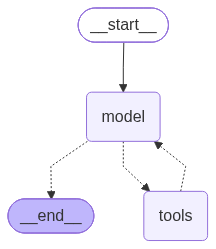

In [30]:
agent

In [31]:
response = agent.invoke({"messages": [{"role":"user", "content": "What's the weather in Banglore?"}]})

response

{'messages': [HumanMessage(content="What's the weather in Banglore?", additional_kwargs={}, response_metadata={}, id='d9ff869f-0a19-4f2f-8b9f-56757d4571b7'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "What\'s the weather in Banglore?" Likely they mean Bangalore (Bengaluru). We have a function get_weather that takes location string. We\'ll call it.', 'tool_calls': [{'id': 'fc_9b75980e-876b-46a1-af4d-527a0831dbfb', 'function': {'arguments': '{"location":"Bangalore"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 137, 'total_tokens': 204, 'completion_time': 0.138806772, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.007240891, 'prompt_tokens_details': None, 'queue_time': 0.314734397, 'total_time': 0.146047663}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3e9f8a8a28', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logp